In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "dkim68_project_summary.csv",
    sep=";"
)

df.head()

,project_wocid,commit_sha1,author,time,commit message
0,jlizier_jidt,001227c730f02caaa878e6e36e076de7c0ca9a9a,Pedro Martinez Mediano <pedro.martinez-mediano...,1495429412,Added Java support for GPU surrogate calculati...
1,jlizier_jidt,001fb764cfac4ee4d374269c91599ca3908c0b7f,joseph.lizier@gmail.com <joseph.lizier@gmail.c...,1407242645,Refactoring discrete TE calculator to take sou...
2,jlizier_jidt,003a187a7a78f681908054c4aa10a79d1f17a28d,jlizier <joseph.lizier@gmail.com>,1662354005,moving the demos using spiking TE estimator in...
3,jlizier_jidt,004812c26494d70e20b299c3169b600b106ff97a,Simon Gimmini <34234300+sgimmini@users.noreply...,1730827821,Merge dca33da1d131d5a446697223f798743449b5c2b0...
4,jlizier_jidt,004a7c7f17396e92a3520824e2e563d625953a93,Pedro Martinez Mediano <pedro.martinez-mediano...,1495039771,"Added separate ant tasks for GPU compilation, ..."


In [3]:
df.columns

Index(['project_wocid', 'commit_sha1', 'author', 'time', 'commit message'], dtype='str')

In [4]:
df["datetime"] = pd.to_datetime(
    df["time"],
    unit="s"
)

df["month"] = df["datetime"].dt.to_period("M")

In [5]:
project = "jlizier_jidt"

project_df = df[df["project_wocid"] == project].copy()

monthly = (
    project_df
    .groupby("month")
    .size()
    .rename("#Commits")
)

In [6]:
all_months = pd.period_range(
    start=project_df["month"].min(),
    end=project_df["month"].max(),
    freq="M"
)

monthly = monthly.reindex(
    all_months,
    fill_value=0
)

monthly.index.name = "Month"
monthly = monthly.reset_index()

monthly["Month"] = monthly["Month"].astype(str)

monthly.head()

,Month,#Commits
0,2012-05,4
1,2012-06,4
2,2012-07,28
3,2012-08,40
4,2012-09,6


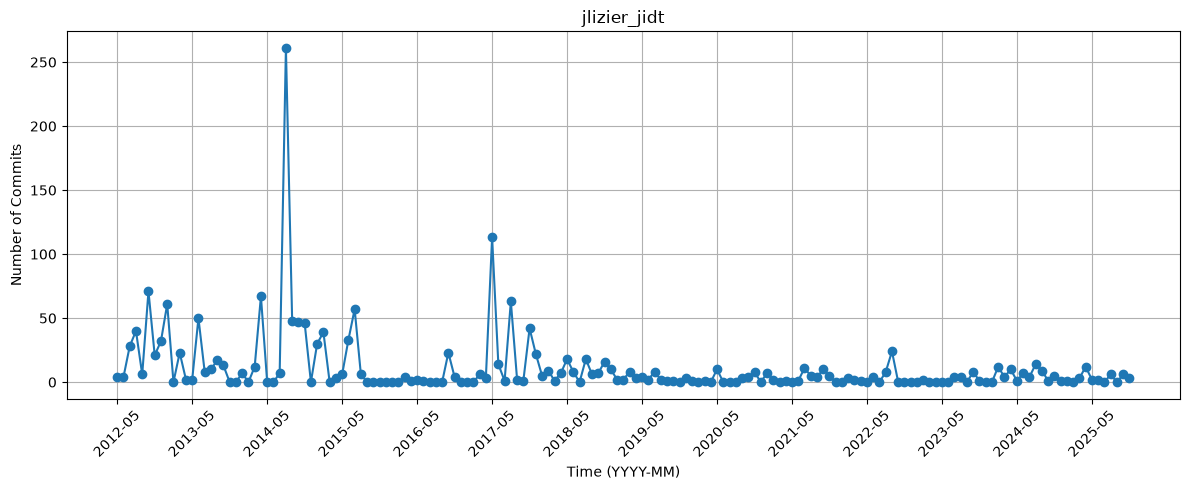

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly["Month"],
    monthly["#Commits"],
    marker="o"
)

plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title(project)
plt.grid(True)

plt.xticks(
    range(0, len(monthly), 12),
    monthly["Month"].iloc[::12],
    rotation=45
)

plt.tight_layout()

plt.savefig(
    f"dkim68_timeseries_{project}.png",
    dpi=300
)

plt.show()

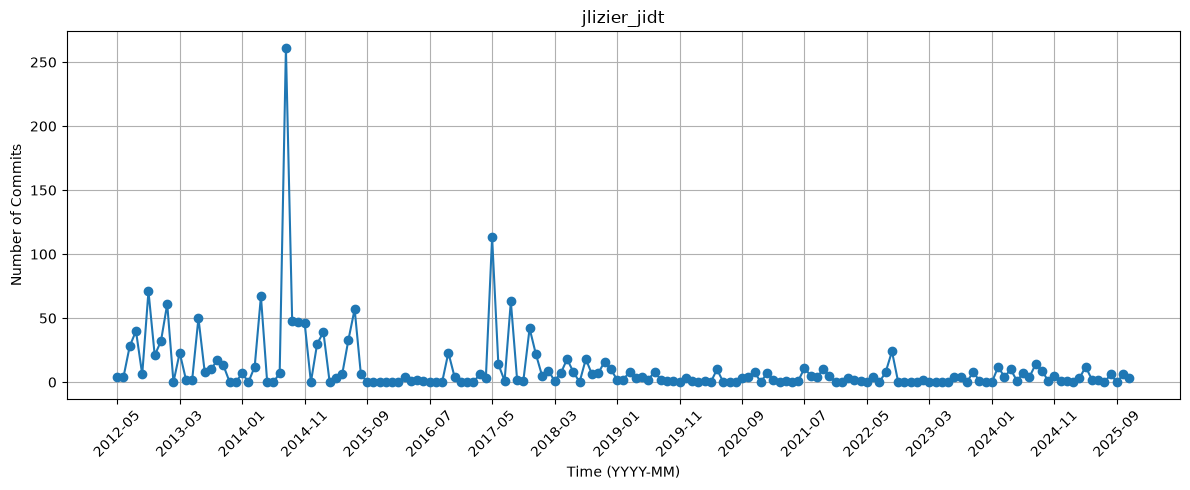

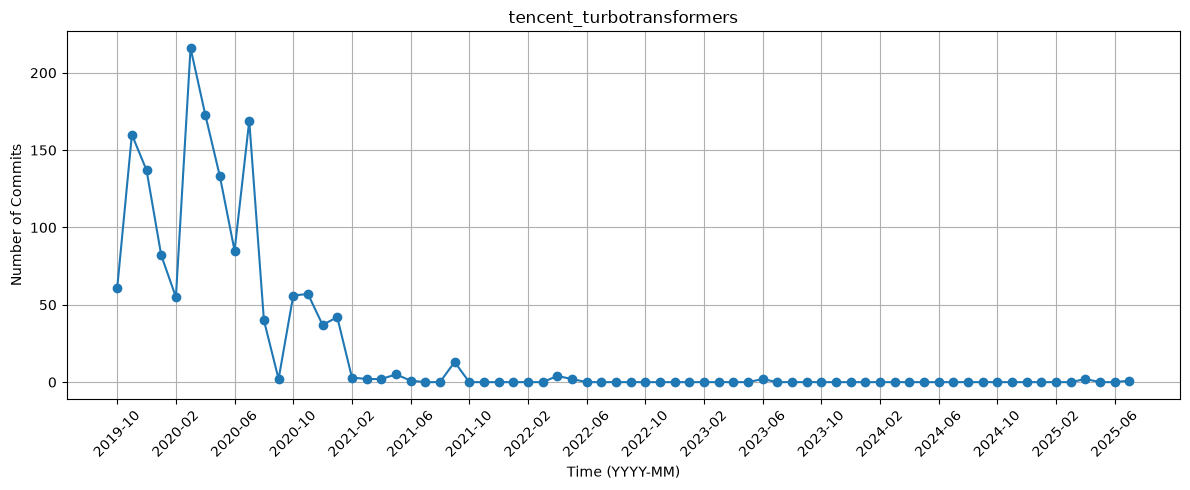

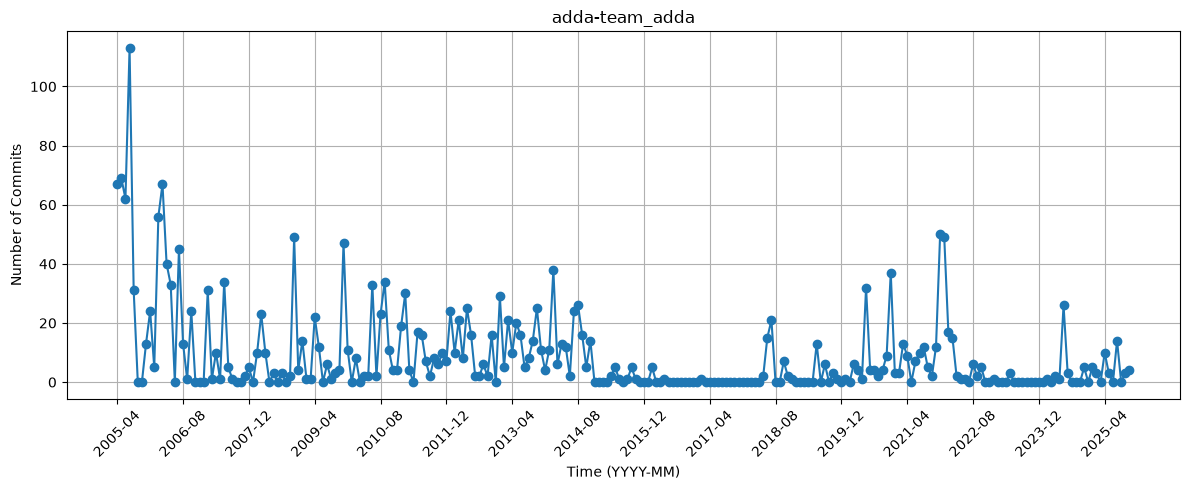

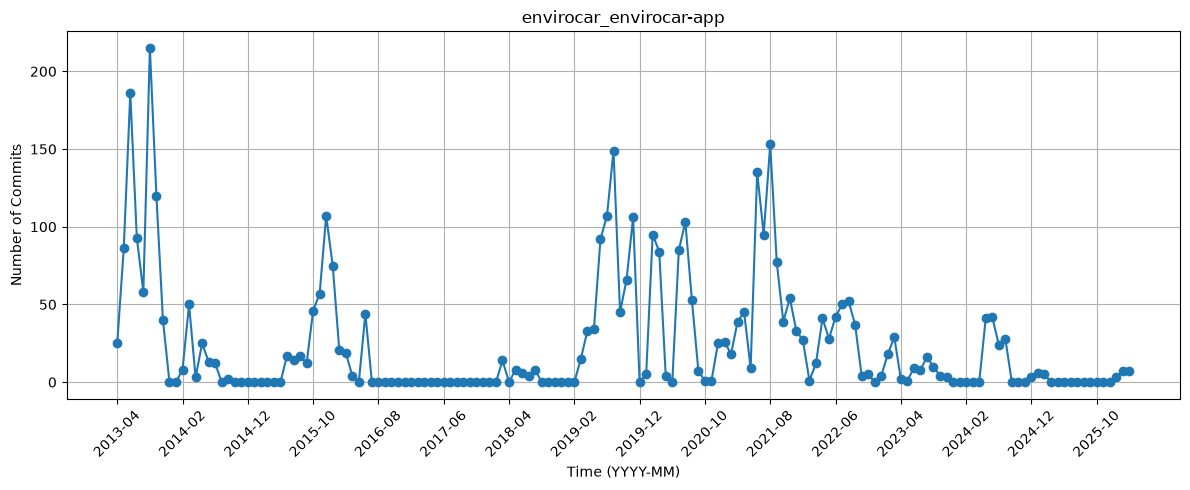

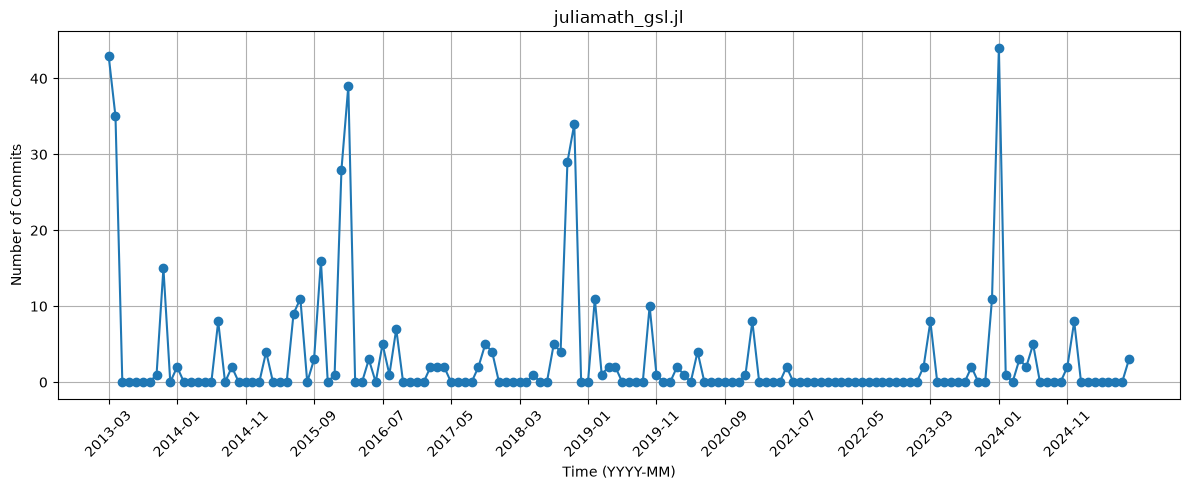

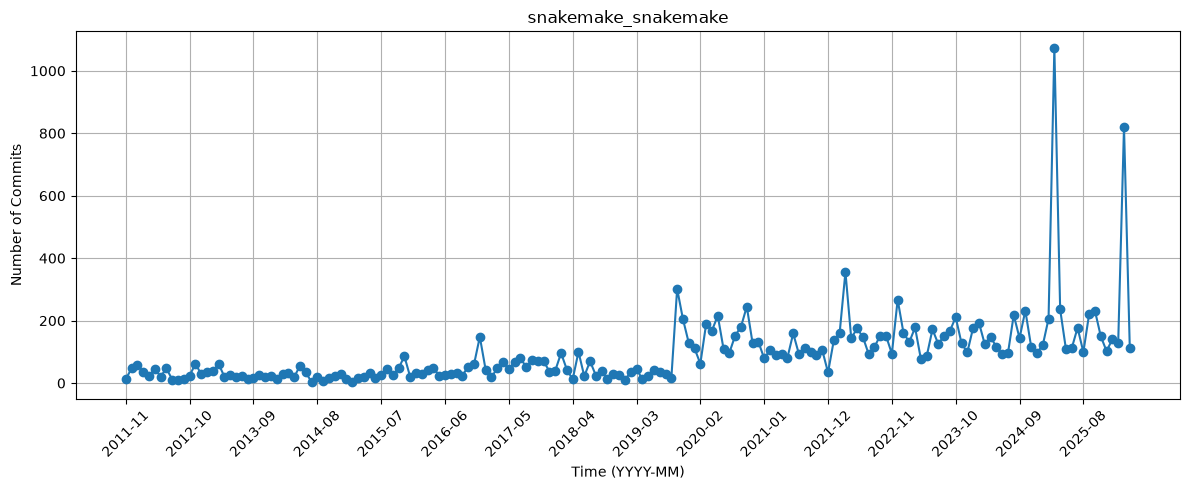

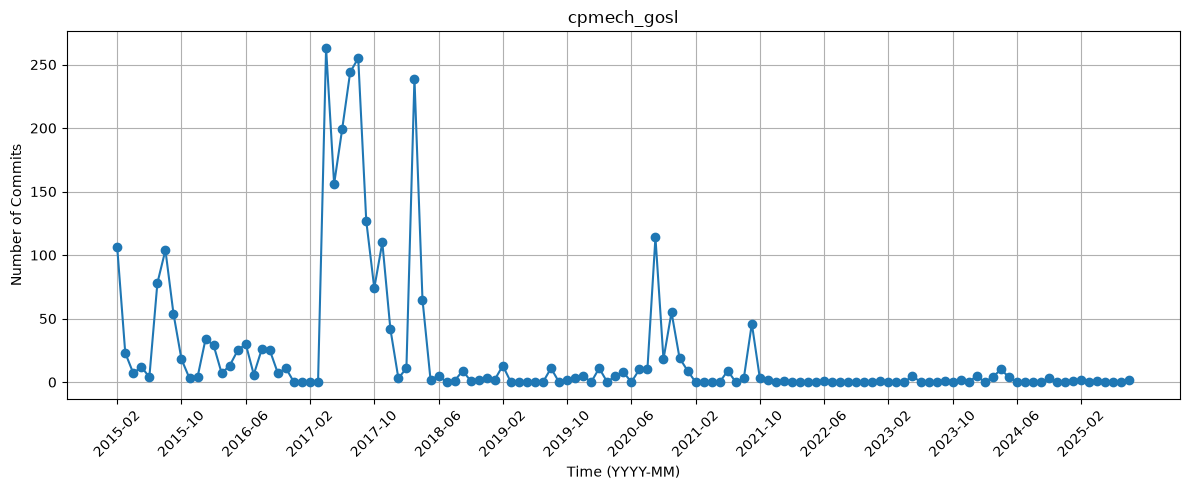

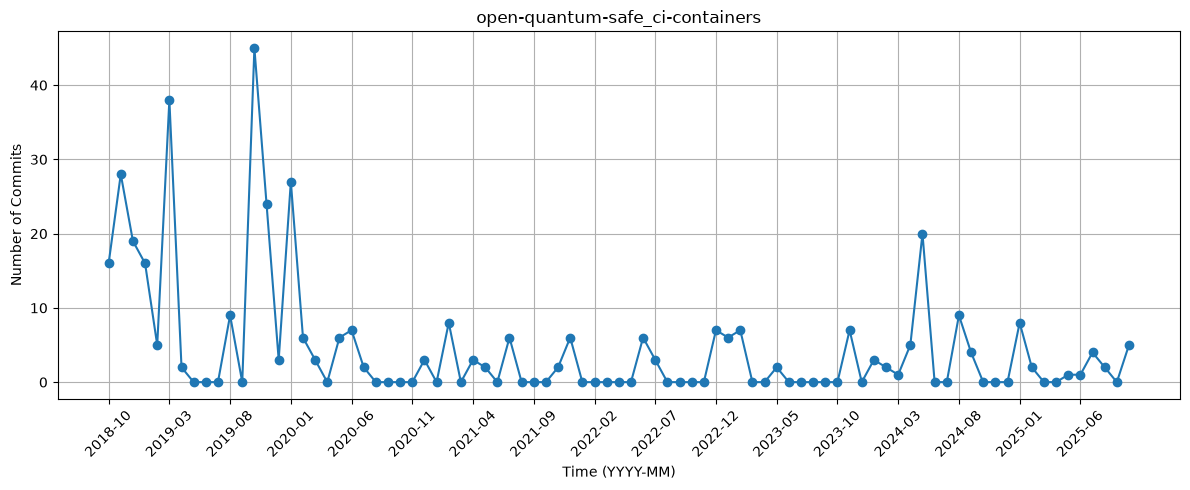

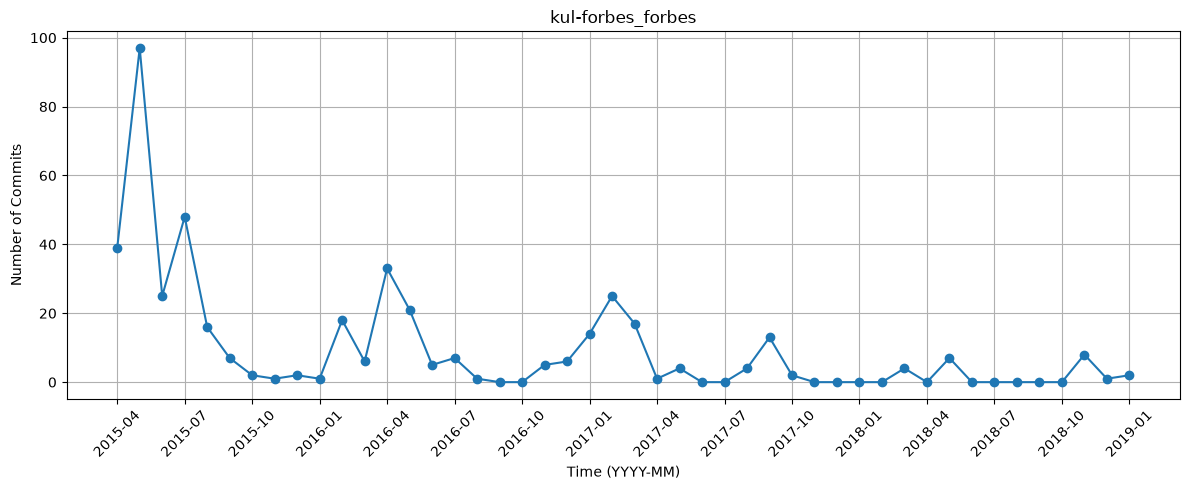

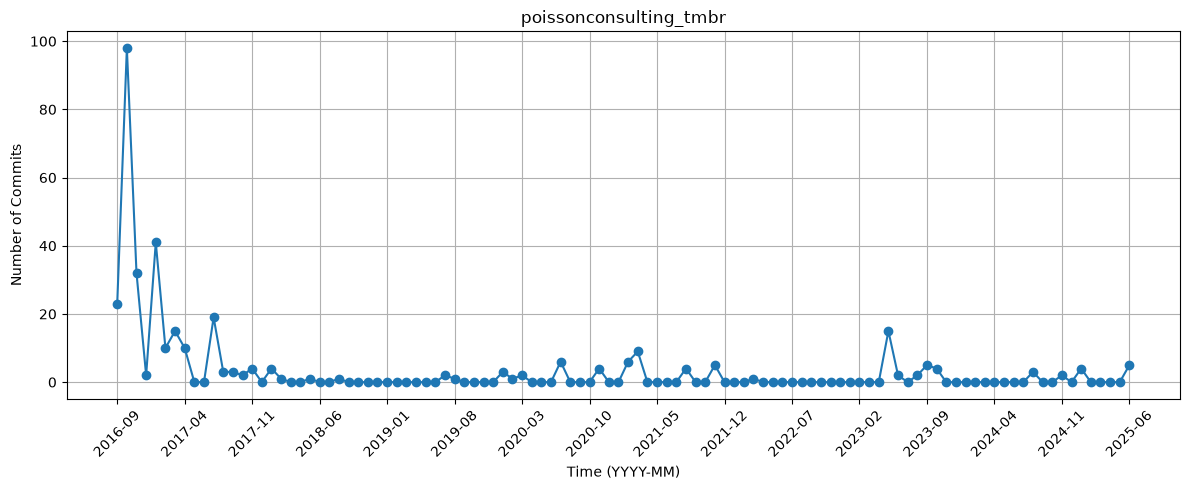

In [8]:
all_timeseries = {}

for project in df["project_wocid"].unique():

    project_df = df[
        df["project_wocid"] == project
    ].copy()

    monthly = (
        project_df
        .groupby("month")
        .size()
        .rename("#Commits")
    )

    all_months = pd.period_range(
        start=project_df["month"].min(),
        end=project_df["month"].max(),
        freq="M"
    )

    monthly = monthly.reindex(
        all_months,
        fill_value=0
    )

    monthly.index.name = "Month"
    monthly = monthly.reset_index()
    monthly["Month"] = monthly["Month"].astype(str)

    all_timeseries[project] = monthly

    plt.figure(figsize=(12, 5))

    plt.plot(
        monthly["Month"],
        monthly["#Commits"],
        marker="o"
    )

    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title(project)
    plt.grid(True)

    step = max(1, len(monthly) // 15)

    plt.xticks(
        range(0, len(monthly), step),
        monthly["Month"].iloc[::step],
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        f"dkim68_timeseries_{project}.png",
        dpi=300
    )

    plt.show()

In [9]:
def analyze_gaps(monthly):

    zero_months = monthly["#Commits"] == 0

    gaps = []
    start = None

    for i, is_zero in enumerate(zero_months):

        if is_zero and start is None:
            start = i

        elif not is_zero and start is not None:
            gaps.append((start, i - 1))
            start = None

    # If timeline ends during a zero-commit gap
    if start is not None:
        gaps.append((start, len(monthly) - 1))

    # No gaps at all
    if len(gaps) == 0:
        return None, None, 0, 0, 0

    # Find longest gap
    longest = max(
        gaps,
        key=lambda x: x[1] - x[0] + 1
    )

    longest_start = monthly.loc[longest[0], "Month"]
    longest_end = monthly.loc[longest[1], "Month"]

    longest_length = (
        longest[1] - longest[0] + 1
    )

    # Count gaps of at least 3 months
    number_of_gaps = sum(
        1
        for start, end in gaps
        if end - start + 1 >= 3
    )

    # Number of commits after longest gap
    commits_after_gap = monthly.loc[
        longest[1] + 1:,
        "#Commits"
    ].sum()

    return (
        longest_start,
        longest_end,
        longest_length,
        commits_after_gap,
        number_of_gaps
    )

In [10]:
gap_rows = []

for project, monthly in all_timeseries.items():

    (
        gap_start,
        gap_end,
        gap_length,
        commits_after,
        num_gaps
    ) = analyze_gaps(monthly)

    gap_rows.append({
        "Project": project,
        "LongestGapStart": gap_start,
        "LongestGapEnd": gap_end,
        "LongestGapLength": gap_length,
        "NumCommitsAfterLastGap": commits_after,
        "NumberOfGapsInTimeline": num_gaps
    })

gap_stats = pd.DataFrame(gap_rows)

gap_stats

,Project,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,jlizier_jidt,2015-09,2016-02,6,680,6
1,tencent_turbotransformers,2023-07,2025-03,21,3,3
2,adda-team_adda,2017-03,2018-04,14,483,9
3,envirocar_envirocar-app,2016-07,2018-02,20,2442,6
4,juliamath_gsl.jl,2021-07,2023-01,19,91,14
5,snakemake_snakemake,NaN,NaN,0,0,0
6,cpmech_gosl,2022-07,2022-12,6,41,9
7,open-quantum-safe_ci-containers,2022-01,2022-05,5,105,7
8,kul-forbes_forbes,2018-06,2018-10,5,11,2
9,poissonconsulting_tmbr,2022-04,2023-04,13,42,9


In [11]:
def analyze_gaps(monthly):

    zero_months = monthly["#Commits"] == 0

    gaps = []
    start = None

    for i, is_zero in enumerate(zero_months):

        if is_zero and start is None:
            start = i

        elif not is_zero and start is not None:
            gaps.append((start, i - 1))
            start = None

    # If timeline ends during a zero-commit gap
    if start is not None:
        gaps.append((start, len(monthly) - 1))

    # No gaps at all
    if len(gaps) == 0:
        return None, None, 0, 0, 0

    # Find longest gap
    longest = max(
        gaps,
        key=lambda x: x[1] - x[0] + 1
    )

    longest_start = monthly.loc[longest[0], "Month"]
    longest_end = monthly.loc[longest[1], "Month"]

    longest_length = (
        longest[1] - longest[0] + 1
    )

    # Count gaps of at least 3 months
    number_of_gaps = sum(
        1
        for start, end in gaps
        if end - start + 1 >= 3
    )

    # Number of commits after longest gap
    commits_after_gap = monthly.loc[
        longest[1] + 1:,
        "#Commits"
    ].sum()

    return (
        longest_start,
        longest_end,
        longest_length,
        commits_after_gap,
        number_of_gaps
    )

In [12]:
gap_rows = []

for project, monthly in all_timeseries.items():

    (
        gap_start,
        gap_end,
        gap_length,
        commits_after,
        num_gaps
    ) = analyze_gaps(monthly)

    gap_rows.append({
        "Project": project,
        "LongestGapStart": gap_start,
        "LongestGapEnd": gap_end,
        "LongestGapLength": gap_length,
        "NumCommitsAfterLastGap": commits_after,
        "NumberOfGapsInTimeline": num_gaps
    })

gap_stats = pd.DataFrame(gap_rows)

gap_stats

,Project,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,jlizier_jidt,2015-09,2016-02,6,680,6
1,tencent_turbotransformers,2023-07,2025-03,21,3,3
2,adda-team_adda,2017-03,2018-04,14,483,9
3,envirocar_envirocar-app,2016-07,2018-02,20,2442,6
4,juliamath_gsl.jl,2021-07,2023-01,19,91,14
5,snakemake_snakemake,NaN,NaN,0,0,0
6,cpmech_gosl,2022-07,2022-12,6,41,9
7,open-quantum-safe_ci-containers,2022-01,2022-05,5,105,7
8,kul-forbes_forbes,2018-06,2018-10,5,11,2
9,poissonconsulting_tmbr,2022-04,2023-04,13,42,9


In [13]:
activity_patterns = {
    "jlizier_jidt": "declining",
    "tencent_turbotransformers": "declining",
    "adda-team_adda": "declining",
    "envirocar_envirocar-app": "irregular",
    "juliamath_gsl.jl": "irregular",
    "snakemake_snakemake": "rising",
    "cpmech_gosl": "declining",
    "open-quantum-safe_ci-containers": "declining",
    "kul-forbes_forbes": "declining",
    "poissonconsulting_tmbr": "declining"
}

gap_stats["ActivityPattern"] = gap_stats["Project"].map(activity_patterns)

gap_stats

,Project,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,jlizier_jidt,2015-09,2016-02,6,680,6,declining
1,tencent_turbotransformers,2023-07,2025-03,21,3,3,declining
2,adda-team_adda,2017-03,2018-04,14,483,9,declining
3,envirocar_envirocar-app,2016-07,2018-02,20,2442,6,irregular
4,juliamath_gsl.jl,2021-07,2023-01,19,91,14,irregular
5,snakemake_snakemake,NaN,NaN,0,0,0,rising
6,cpmech_gosl,2022-07,2022-12,6,41,9,declining
7,open-quantum-safe_ci-containers,2022-01,2022-05,5,105,7,declining
8,kul-forbes_forbes,2018-06,2018-10,5,11,2,declining
9,poissonconsulting_tmbr,2022-04,2023-04,13,42,9,declining


In [14]:
gap_stats.to_csv(
    "dkim68_project_stats.csv",
    sep=";",
    index=False
)

## Interpretation
jlizier_jidt - declining: Activity was much higher in the early years, with several large spikes, but after about 2018 the project stayed at a much lower activity level. It has 6 inactivity gaps of at least three months.

tencent_turbotransformers - declining: The project was highly active around 2019–2020, then activity dropped sharply and remained near zero after 2021. It has 3 inactivity gaps, including a very long 21-month gap.

adda-team_adda - declining: Activity was relatively high and frequent in the early years, but became much lower and more intermittent later. There are occasional bursts of activity, but the long-term pattern is downward, with 9 inactivity gaps.

envirocar_envirocar-app - irregular: Activity occurs in strong bursts separated by long inactive periods. There are several major peaks around 2013, 2019, and 2021, followed by lower activity in recent years; there are 6 inactivity gaps.

juliamath_gsl.jl - irregular: Most months have very few or no commits, but there are occasional large spikes throughout the project history. The activity does not show a consistent rising or declining trend, and there are 14 inactivity gaps.

snakemake_snakemake - rising: Commit activity generally increases over time, especially after 2019, with much higher monthly activity and several very large recent spikes. Your data found no zero-commit inactivity gaps.

cpmech_gosl - declining: The project had very high activity around 2017, followed by progressively lower activity. Since about 2022, commits have been very sparse, and the project has 9 inactivity gaps.

open-quantum-safe_ci-containers - declining: The project had its highest activity in 2018–2020, then activity became much lower and more sporadic. Small bursts still occur, but the overall level has declined, with 7 inactivity gaps.

kul-forbes_forbes - declining: Activity was highest near the beginning of the project and steadily became lower and more intermittent. By the later period, most months contain few or no commits, with 2 inactivity gaps.

poissonconsulting_tmbr - declining: The project had a very large burst of activity near its beginning, followed by mostly low or zero monthly activity. There are occasional later spikes, but overall activity is much lower than at the start, with 9 inactivity gaps.

In [15]:
import requests
import pandas as pd

projects = [
    'jlizier/jidt',
    'tencent/turbotransformers',
    'adda-team/adda',
    'envirocar/envirocar-app',
    'juliamath/gsl.jl',
    'snakemake/snakemake',
    'cpmech/gosl',
    'open-quantum-safe/ci-containers',
    'kul-forbes/forbes',
    'poissonconsulting/tmbr'
]

# GitHub summary
rows = []

for repo in projects:
    repo_data = requests.get(
        f"https://api.github.com/repos/{repo}"
    ).json()

    commits = requests.get(
        f"https://api.github.com/repos/{repo}/commits",
        params={"per_page": 1}
    ).json()

    if commits and isinstance(commits, list):
        last_commit_date = commits[0]["commit"]["committer"]["date"]
    else:
        last_commit_date = None

    rows.append({
        "repo": repo,
        "nstars": repo_data.get("stargazers_count"),
        "nforks": repo_data.get("forks_count"),
        "lastGHCommitDate": last_commit_date
    })

github_stats = pd.DataFrame(rows)

github_stats["Project"] = (
    github_stats["repo"]
    .str.lower()
    .str.replace("/", "_", regex=False)
)

In [16]:
commit_df = pd.read_csv(
    "dkim68_project_summary.csv",
    sep=";"
)

commit_df["datetime"] = pd.to_datetime(
    commit_df["time"],
    unit="s"
)

woc_stats = (
    commit_df
    .groupby("project_wocid")
    .agg(
        ncommits=("commit_sha1", "count"),
        nauthors=("author", "nunique"),
        from_date=("datetime", "min"),
        to_date=("datetime", "max")
    )
    .reset_index()
)

woc_stats = woc_stats.rename(
    columns={
        "project_wocid": "Project",
        "from_date": "from",
        "to_date": "to"
    }
)

In [17]:
final_stats = (
    woc_stats
    .merge(
        github_stats[
            [
                "Project",
                "nstars",
                "nforks",
                "lastGHCommitDate"
            ]
        ],
        on="Project",
        how="left"
    )
    .merge(
        gap_stats,
        on="Project",
        how="left"
    )
)

final_stats

,Project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,adda-team_adda,2200,48,2005-04-07 09:24:16,2025-10-15 12:41:27,132,66,2026-03-30T08:45:28Z,2017-03,2018-04,14,483,9,declining
1,cpmech_gosl,2838,27,2015-02-09 23:00:38,2025-08-07 21:33:55,1884,148,2026-09-28T08:58:18Z,2022-07,2022-12,6,41,9,declining
2,envirocar_envirocar-app,3811,105,2013-04-10 08:53:02,2026-03-03 10:56:29,88,158,2026-02-10T12:09:53Z,2016-07,2018-02,20,2442,6,irregular
3,jlizier_jidt,1741,27,2012-05-07 23:25:25,2025-11-05 04:14:00,306,83,2026-08-03T02:27:32Z,2015-09,2016-02,6,680,6,declining
4,juliamath_gsl.jl,459,51,2013-03-27 05:40:57,2025-08-14 15:06:31,101,30,2026-06-22T14:28:28Z,2021-07,2023-01,19,91,14,irregular
5,kul-forbes_forbes,442,12,2015-04-24 17:36:12,2019-01-18 09:27:43,27,11,2025-01-27T13:40:34Z,2018-06,2018-10,5,11,2,declining
6,open-quantum-safe_ci-containers,391,32,2018-10-17 17:40:20,2025-10-25 06:51:44,5,14,2026-09-28T13:10:36Z,2022-01,2022-05,5,105,7,declining
7,poissonconsulting_tmbr,355,24,2016-09-20 19:57:04,2025-06-03 22:41:20,0,1,2026-09-01T07:20:55Z,2022-04,2023-04,13,42,9,declining
8,snakemake_snakemake,16416,804,2011-11-13 22:33:28,2026-04-18 11:32:12,2882,663,2026-09-28T15:05:27Z,NaN,NaN,0,0,0,rising
9,tencent_turbotransformers,1542,45,2019-10-28 03:29:53,2025-07-18 03:51:17,1551,208,2025-07-18T03:51:17Z,2023-07,2025-03,21,3,3,declining


In [18]:
final_stats.to_csv(
    "dkim68_project_stats.csv",
    sep=";",
    index=False
)

# Part 3 - Commits Before and After Longest Gap

In [20]:
import pandas as pd

# Commit-level data from Part 1
commits = pd.read_csv(
    "dkim68_project_summary.csv",
    sep=";"
)

# Summary/gap data from Parts 1 and 2
stats = pd.read_csv(
    "dkim68_project_stats.csv",
    sep=";"
)

# Convert commit time to datetime
commits["datetime"] = pd.to_datetime(
    commits["time"],
    unit="s"
)

commits.head()

,project_wocid,commit_sha1,author,time,commit message,datetime
0,jlizier_jidt,001227c730f02caaa878e6e36e076de7c0ca9a9a,Pedro Martinez Mediano <pedro.martinez-mediano...,1495429412,Added Java support for GPU surrogate calculati...,2017-05-22 05:03:32
1,jlizier_jidt,001fb764cfac4ee4d374269c91599ca3908c0b7f,joseph.lizier@gmail.com <joseph.lizier@gmail.c...,1407242645,Refactoring discrete TE calculator to take sou...,2014-08-05 12:44:05
2,jlizier_jidt,003a187a7a78f681908054c4aa10a79d1f17a28d,jlizier <joseph.lizier@gmail.com>,1662354005,moving the demos using spiking TE estimator in...,2022-09-05 05:00:05
3,jlizier_jidt,004812c26494d70e20b299c3169b600b106ff97a,Simon Gimmini <34234300+sgimmini@users.noreply...,1730827821,Merge dca33da1d131d5a446697223f798743449b5c2b0...,2024-11-05 17:30:21
4,jlizier_jidt,004a7c7f17396e92a3520824e2e563d625953a93,Pedro Martinez Mediano <pedro.martinez-mediano...,1495039771,"Added separate ant tasks for GPU compilation, ...",2017-05-17 16:49:31


In [21]:
gap_commit_rows = []

for _, row in stats.iterrows():

    project = row["Project"]
    gap_start = row["LongestGapStart"]
    gap_end = row["LongestGapEnd"]

    # No inactivity gap
    if pd.isna(gap_start) or pd.isna(gap_end):
        print(f"{project}: no inactivity gap")
        continue

    project_commits = commits[
        commits["project_wocid"] == project
    ].copy()

    project_commits = project_commits.sort_values("datetime")

    # First day of gap
    gap_start_date = pd.Period(
        gap_start,
        freq="M"
    ).start_time

    # First day AFTER gap
    after_gap_date = (
        pd.Period(gap_end, freq="M") + 1
    ).start_time

    # Last 10 before gap
    pre = (
        project_commits[
            project_commits["datetime"] < gap_start_date
        ]
        .tail(10)
        .copy()
    )

    # First 10 after gap
    post = (
        project_commits[
            project_commits["datetime"] >= after_gap_date
        ]
        .head(10)
        .copy()
    )

    pre["pre/post"] = "pre"
    post["pre/post"] = "post"

    gap_commit_rows.append(pre)
    gap_commit_rows.append(post)

snakemake_snakemake: no inactivity gap


In [22]:
gap_commits = pd.concat(
    gap_commit_rows,
    ignore_index=True
)

gap_commits = gap_commits[
    [
        "pre/post",
        "project_wocid",
        "commit_sha1",
        "author",
        "time",
        "commit message"
    ]
]

gap_commits.columns = [
    "pre/post",
    "prj",
    "commit",
    "author",
    "time",
    "message"
]

gap_commits.to_csv(
    "dkim68_project_gap_commits.csv",
    sep=";",
    index=False
)

gap_commits.head(20)

,pre/post,prj,commit,author,time,message
0,pre,adda-team_adda,b828f792e9a110a561c9c66ff17faf3092c6449a,Maxim Yurkin <yurkin@gmail.com>,1443167947,Merge pull request #211 from mapclyps/master\n...
1,pre,adda-team_adda,46817567630e0084cda76e86cf0b4e7283d68399,Marcus Huntemann <marcus.huntemann@gmail.com>,1443522229,added MatVec function wrapper for oclBLAS\n
2,pre,adda-team_adda,be707df719db4e28493257f3da27289b7c54f2be,Marcus Huntemann <marcus.huntemann@gmail.com>,1445088593,Merge pull request #213 from mapclyps/ocl_blas...
3,pre,adda-team_adda,0d3f22bc2251d81229c9c2a26721bc7868cd6011,Maxim Yurkin <yurkin@gmail.com>,1456338502,Add missing dlls for pip.exe
4,pre,adda-team_adda,de9280974914026d75ac6c1ce01d72a579a6392d,Maxim Yurkin <yurkin@gmail.com>,1456338532,Add missing dlls for pip.exe
5,pre,adda-team_adda,b26b20239c68706e236116c33cd2693d01b0bb54,Maxim Yurkin <yurkin@gmail.com>,1456338574,Update dll requirements
6,pre,adda-team_adda,420257135f55f82e000b0bc1355d8a914a644c7b,Maxim Yurkin <yurkin@gmail.com>,1456338639,Update dll requirements
7,pre,adda-team_adda,0ef769d4fca81ea772f858b6d011748340059572,Maxim Yurkin <yurkin@gmail.com>,1456338756,Merge pull request #217 from myurkin/master\n\...
8,pre,adda-team_adda,0a743c5f432e645763729e667bbe299dbe691c97,Maxim Yurkin <yurkin@gmail.com>,1464006139,Created README based on ../wiki/ProjectHome.md
9,pre,adda-team_adda,6d3c9fcba53a2551cd87168659f931cebcee7f5b,Maxim Yurkin <yurkin@gmail.com>,1487322955,Permanent links to issues


In [23]:
gap_commits.groupby(
    ["prj", "pre/post"]
).size()

prj                              pre/post
adda-team_adda                   post        10
                                 pre         10
cpmech_gosl                      post        10
                                 pre         10
envirocar_envirocar-app          post        10
                                 pre         10
jlizier_jidt                     post        10
                                 pre         10
juliamath_gsl.jl                 post        10
                                 pre         10
kul-forbes_forbes                post        10
                                 pre         10
open-quantum-safe_ci-containers  post        10
                                 pre         10
poissonconsulting_tmbr           post        10
                                 pre         10
tencent_turbotransformers        post         3
                                 pre         10
dtype: int64

In [24]:
for project in gap_commits["prj"].unique():

    print("\n==============================")
    print(project)
    print("==============================")

    for period in ["pre", "post"]:

        print(f"\n--- {period.upper()} ---")

        display(
            gap_commits[
                (gap_commits["prj"] == project) &
                (gap_commits["pre/post"] == period)
            ][["message"]]
        )


adda-team_adda

--- PRE ---


,message
0,Merge pull request #211 from mapclyps/master\n...
1,added MatVec function wrapper for oclBLAS\n
2,Merge pull request #213 from mapclyps/ocl_blas...
3,Add missing dlls for pip.exe
4,Add missing dlls for pip.exe
5,Update dll requirements
6,Update dll requirements
7,Merge pull request #217 from myurkin/master\n\...
8,Created README based on ../wiki/ProjectHome.md
9,Permanent links to issues



--- POST ---


,message
10,Rename doc/copyleft to LICENSE
11,master to rect_dip\n
12,local gitignore\n
13,polishing after rect_dip merging + gitignore f...
14,polishing after rect_dip merging + gitignore f...
15,sute for rect_dip\n
16,fix code style (legacy from rect_dip branch)\n
17,comp2exec was renamed to comp2exec.sh for bett...
18,comp2exec was renamed to comp2exec.sh for bett...
19,test suite [for case 'rect_dip 1 1 1'] was add...



cpmech_gosl

--- PRE ---


...

,message
150,Bump\n
151,Update workflows\n
152,Suggest RcppEigen\n
153,fix tests\n
154,fix up read me\n
155,fix test warnings\n
156,remove unused dependencies\n
157,update actions\n
158,Deploying to gh-pages from @ poissonconsulting...
159,add RcppEigen\n



tencent_turbotransformers

--- PRE ---


,message
160,Update README.md
161,Update README.md (#250)\n\n
162,Add conda_environment.cpu.yml to maintain pack...
163,Update Dockerfile_dev.cpu\n
164,update Dockerfile_dev.cpu\n
165,add conda_environment_release.cpu.yml to maint...
166,add zh-cn config\n
167,update\n
168,Bump transformers from 4.11.1 to 4.30.0\n\nBum...
169,Merge 19833ca90728ba31f236b0c7af18355b61e24e03...



--- POST ---


,message
170,Update requirements.txt
171,Bump transformers from 4.11.1 to 4.30.0 (#272)...
172,Update requirements.txt


In [25]:
before_themes = {
    "adda-team_adda": "Feature development:Documentation updates",
    "cpmech_gosl": "Documentation updates:Bug fixes",
    "envirocar_envirocar-app": "Bug fixes:Release",
    "jlizier_jidt": "Documentation updates:Release",
    "juliamath_gsl.jl": "Documentation updates:Dependency updates",
    "kul-forbes_forbes": "Feature development:Bug fixes",
    "open-quantum-safe_ci-containers": "Dependency updates:Bug fixes",
    "poissonconsulting_tmbr": "Automated bot contributions:Documentation updates",
    "tencent_turbotransformers": "Dependency updates:Documentation updates",
    "snakemake_snakemake": "N/A"
}

after_themes = {
    "adda-team_adda": "Bug fixes:Feature development",
    "cpmech_gosl": "Bug fixes:Dependency updates",
    "envirocar_envirocar-app": "Bug fixes:Feature development",
    "jlizier_jidt": "Feature development:Bug fixes",
    "juliamath_gsl.jl": "Dependency updates:Automated bot contributions",
    "kul-forbes_forbes": "Bug fixes:Feature development",
    "open-quantum-safe_ci-containers": "Feature development:Dependency updates",
    "poissonconsulting_tmbr": "Bug fixes:Dependency updates",
    "tencent_turbotransformers": "Dependency updates:Bug fixes",
    "snakemake_snakemake": "N/A"
}

In [26]:
stats["BeforeThemes"] = stats["Project"].map(before_themes)
stats["AfterThemes"] = stats["Project"].map(after_themes)

stats.to_csv(
    "dkim68_project_stats.csv",
    sep=";",
    index=False
)

stats[
    ["Project", "BeforeThemes", "AfterThemes"]
]

,Project,BeforeThemes,AfterThemes
0,adda-team_adda,Feature development:Documentation updates,Bug fixes:Feature development
1,cpmech_gosl,Documentation updates:Bug fixes,Bug fixes:Dependency updates
2,envirocar_envirocar-app,Bug fixes:Release,Bug fixes:Feature development
3,jlizier_jidt,Documentation updates:Release,Feature development:Bug fixes
4,juliamath_gsl.jl,Documentation updates:Dependency updates,Dependency updates:Automated bot contributions
5,kul-forbes_forbes,Feature development:Bug fixes,Bug fixes:Feature development
6,open-quantum-safe_ci-containers,Dependency updates:Bug fixes,Feature development:Dependency updates
7,poissonconsulting_tmbr,Automated bot contributions:Documentation updates,Bug fixes:Dependency updates
8,snakemake_snakemake,N/A,N/A
9,tencent_turbotransformers,Dependency updates:Documentation updates,Dependency updates:Bug fixes


# Part 4 - Interpret the Gaps

In [27]:
stats["HypothesizedGapReason"] = ""
stats["HasRecovered"] = ""
stats["WhyRecovered"] = ""
stats["WhoRecovered"] = ""
stats["Currentstatus"] = ""
stats["RecentThemes"] = ""
stats["Notes"] = ""

In [28]:
stats["lastGHCommitDate"] = pd.to_datetime(
    stats["lastGHCommitDate"],
    utc=True
)

cutoff = pd.Timestamp("2025-04-01", tz="UTC")

stats["Currentstatus"] = stats["lastGHCommitDate"].apply(
    lambda x: "Inactive" if x < cutoff else "Active"
)

stats[["Project", "lastGHCommitDate", "Currentstatus"]]

,Project,lastGHCommitDate,Currentstatus
0,adda-team_adda,2026-03-30 08:45:28+00:00,Active
1,cpmech_gosl,2026-09-28 08:58:18+00:00,Active
2,envirocar_envirocar-app,2026-02-10 12:09:53+00:00,Active
3,jlizier_jidt,2026-08-03 02:27:32+00:00,Active
4,juliamath_gsl.jl,2026-06-22 14:28:28+00:00,Active
5,kul-forbes_forbes,2025-01-27 13:40:34+00:00,Inactive
6,open-quantum-safe_ci-containers,2026-09-28 13:10:36+00:00,Active
7,poissonconsulting_tmbr,2026-09-01 07:20:55+00:00,Active
8,snakemake_snakemake,2026-09-28 15:05:27+00:00,Active
9,tencent_turbotransformers,2025-07-18 03:51:17+00:00,Active


In [29]:
recent_commits = (
    commits
    .sort_values("datetime")
    .groupby("project_wocid")
    .tail(10)
)

for project in recent_commits["project_wocid"].unique():

    print("\n==============================")
    print(project)
    print("==============================")

    display(
        recent_commits[
            recent_commits["project_wocid"] == project
        ][["datetime", "author", "commit message"]]
    )


kul-forbes_forbes


,datetime,author,commit message
29460,2018-11-01 14:27:06,mkrishan <manish.krishanlal@esat.kuleuven.be>,fixed error\n
29483,2018-11-01 19:55:19,Manish KL Arora <manish.krishanlal@esat.kuleuv...,Delete results.csv
29637,2018-11-02 19:52:39,mkrishan <manish.krishanlal@esat.kuleuven.be>,"ruix equilibration worsens results, so kept ja..."
29642,2018-11-02 19:54:46,mkrishan <manish.krishanlal@esat.kuleuven.be>,Merge branch 'nama-qp' of https://github.com/k...
29650,2018-11-03 17:06:47,mkrishan <manish.krishanlal@esat.kuleuven.be>,small update\n
29676,2018-11-05 09:56:12,mkrishan <manish.krishanlal@esat.kuleuven.be>,Lipshitz constant\n
29473,2018-11-14 17:21:26,mkrishan <manish.krishanlal@esat.kuleuven.be>,fixed adaptive\n
29814,2018-12-28 18:27:55,mkrishan <manish.krishanlal@esat.kuleuven.be>,"added FB-trust-region, trucated-newton\n"
29787,2019-01-18 09:25:36,mkrishan <manish.krishanlal@esat.kuleuven.be>,reached optimum message-problem not solved\n
29540,2019-01-18 09:27:43,mkrishan <manish.krishanlal@esat.kuleuven.be>,adding a branch-reached optimum message-proble...



tencent_turbotransformers


,datetime,author,commit message
2741,2022-04-28 09:23:49,Neo Fung <neosfung@gmail.com>,Update Dockerfile_dev.cpu\n
3220,2022-04-29 03:33:02,Neo Fung <neosfung@gmail.com>,update Dockerfile_dev.cpu\n
2788,2022-04-29 06:11:51,Neo Fung <neosfung@gmail.com>,add conda_environment_release.cpu.yml to maint...
1831,2022-05-08 05:05:17,Neo@mackbook.tencent <neosfeng@tencent.com>,add zh-cn config\n
2769,2022-05-09 03:15:03,Neo Fung <neosfung@gmail.com>,update\n
1883,2023-06-12 21:32:37,dependabot[bot] <49699333+dependabot[bot]@user...,Bump transformers from 4.11.1 to 4.30.0\n\nBum...
2803,2023-06-12 21:32:40,dependabot[bot] <49699333+dependabot[bot]@user...,Merge 19833ca90728ba31f236b0c7af18355b61e24e03...
2358,2025-04-07 08:11:53,Yang Yu <josephyu@tencent.com>,Update requirements.txt
2386,2025-04-07 08:13:09,dependabot[bot] <49699333+dependabot[bot]@user...,Bump transformers from 4.11.1 to 4.30.0 (#272)...
2212,2025-07-18 03:51:17,Yang Yu <reyoung@126.com>,Update requirements.txt



cpmech_gosl


...

,datetime,author,commit message
923,2025-08-27 05:02:12,Joseph Lizier <joseph.lizier@gmail.com>,Changes to comments on PythonSimpleFunctions n...
1731,2025-10-15 22:17:00,Joseph Lizier <joseph.lizier@gmail.com>,"Targeting Java version 8 in our builds now, in..."
330,2025-10-17 04:09:50,Joseph Lizier <joseph.lizier@gmail.com>,Minor comment changes to Scissors-Paper-Rock n...
1305,2025-10-17 04:10:17,Joseph Lizier <joseph.lizier@gmail.com>,Updating old references to Matlab in Python no...
906,2025-10-24 01:16:15,Joseph Lizier <joseph.lizier@gmail.com>,Updating course module 12 effective network in...
1371,2025-10-28 14:53:24,Donovan Rynne <donovan@drynne.com>,Merge e63df78ea31bced8b400319aa856c723247e8165...
1599,2025-10-28 14:53:24,Brad <46321102+bwootwoot@users.noreply.github....,Merge 1fcf2d0136a05127a18fc76ad143a7577550512d...
67,2025-11-03 02:13:14,Michael <63826035+KnightFizz@users.noreply.git...,Merge a7f774185df327d7cad4061837abea0d3bbf6b90...
1083,2025-11-03 18:19:07,Simon Gimmini <34234300+sgimmini@users.noreply...,Merge dca33da1d131d5a446697223f798743449b5c2b0...
1164,2025-11-05 04:14:00,Joseph Lizier <joseph.lizier@gmail.com>,Module 12 in course: adding code to show how t...



envirocar_envirocar-app


,datetime,author,commit message
5954,2026-02-10 11:26:49,Herbert-Islands\Sebastian <s.drost@52north.org>,Disable mapbox and update maplibre\n
8533,2026-02-10 11:56:53,Herbert-Islands\Sebastian <s.drost@52north.org>,Replace problematic code\n
5596,2026-02-10 12:09:53,Herbert-Islands\Sebastian <s.drost@52north.org>,Raise version code\n
6231,2026-03-03 10:12:42,Jaypalsinh Barad <93068379+Jdbarad@users.norep...,Merge 6f0bfc31300f013edef311e1f01103715f95819d...
6098,2026-03-03 10:17:45,Anam Ansari <anamansari062@gmail.com>,Merge 0de2f5894bdd6a9d15fb35856861348f99cdfb1f...
8778,2026-03-03 10:19:45,Preeti Sarkar <47977131+pree-T@users.noreply.g...,Merge b0b92abd78e76711a1da7d087f11468677637303...
6713,2026-03-03 10:19:51,Dhiraj Chauhan <Chauhandhiraj40@gmail.com>,Merge 7d676a7bcc0d5168eda66a3016fc1e3f6be25e67...
6922,2026-03-03 10:20:23,Dhiraj Chauhan <Chauhandhiraj40@gmail.com>,Merge 0a6834784069200a872032d3f0d3542d8ffa2b02...
6293,2026-03-03 10:21:08,Dhiraj Chauhan <Chauhandhiraj40@gmail.com>,Merge d267cd56fa03eaee78d15619569f5c31cab41339...
7649,2026-03-03 10:56:29,Arvind Negi <negi.arvind03@gmail.com>,Merge 8d753f5eb13f1b6e7f205cd5487e4abdd595627c...



snakemake_snakemake


,datetime,author,commit message
18206,2026-04-17 03:43:05,Fong Chun Chan <fongchunchan@gmail.com>,Merge 769ec0d29fb9672423cdc5c1efd87f310c76e3b7...
13019,2026-04-17 05:06:18,Jared Lumpe <mjlumpe@gmail.com>,Merge 4df0718b78d9ecfa1650e37d31f7200cb5eb4cb3...
19809,2026-04-17 05:06:29,Nils Homer <nh13@users.noreply.github.com>,Merge 0d2b55645c04c0ae58c1702126f18b83d86ec893...
15738,2026-04-17 07:09:57,Till Hartmann <till.hartmann@tu-dortmund.de>,Merge 31018e72569860a28e4493c4b11a4f202a3e9b92...
16698,2026-04-17 09:04:38,Sven Schrinner <sven.schrinner@tu-dortmund.de>,Merge 835101d2bd1baa33941e3b4475f33a010d1471c1...
25398,2026-04-17 10:07:53,Christian Meesters <cmeesters@users.noreply.gi...,Merge a84695f0a53ee707eb27436c253757bc31eb3f3b...
24268,2026-04-17 10:32:20,Ed Bennett <pyedward@swansea.ac.uk>,Merge ffd22063f8796e12bc7d86e44d652a6adc388a11...
10728,2026-04-17 17:45:12,Filipe G. Vieira <1151762+fgvieira@users.norep...,Merge f329cb572e98795175c6fcab22a9ec91d8c0c3d4...
20538,2026-04-17 20:16:12,David Laehnemann <1379875+dlaehnemann@users.no...,Merge 9e8a79c923b193f6d3ad42c8da484bbb1ae8ed6e...
21946,2026-04-18 11:32:12,Jonas Hörsch <coroa@posteo.de>,Merge 93d06667343bddf55ce9bcf2d762b526a2a36843...


In [30]:
recent_themes = {
    "kul-forbes_forbes": "Bug fixes:Feature development",
    "tencent_turbotransformers": "Dependency updates:Automated bot contributions",
    "cpmech_gosl": "Bug fixes:Documentation updates",
    "poissonconsulting_tmbr": "Documentation updates:Automated bot contributions",
    "juliamath_gsl.jl": "Dependency updates:Automated bot contributions",
    "open-quantum-safe_ci-containers": "Feature development:Dependency updates",
    "adda-team_adda": "Documentation updates:Bug fixes",
    "jlizier_jidt": "Documentation updates:Feature development",
    "envirocar_envirocar-app": "Feature development:Bug fixes",
    "snakemake_snakemake": "Feature development:Other"
}

In [31]:
stats["RecentThemes"] = stats["Project"].map(recent_themes)

stats[
    ["Project", "Currentstatus", "RecentThemes"]
]

,Project,Currentstatus,RecentThemes
0,adda-team_adda,Active,Documentation updates:Bug fixes
1,cpmech_gosl,Active,Bug fixes:Documentation updates
2,envirocar_envirocar-app,Active,Feature development:Bug fixes
3,jlizier_jidt,Active,Documentation updates:Feature development
4,juliamath_gsl.jl,Active,Dependency updates:Automated bot contributions
5,kul-forbes_forbes,Inactive,Bug fixes:Feature development
6,open-quantum-safe_ci-containers,Active,Feature development:Dependency updates
7,poissonconsulting_tmbr,Active,Documentation updates:Automated bot contributions
8,snakemake_snakemake,Active,Feature development:Other
9,tencent_turbotransformers,Active,Dependency updates:Automated bot contributions
